In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

In [2]:
df = pd.read_csv("MagicBricksProject_Cleaned_Data.csv")

In [3]:
df.head(5)

,City,BHK,Location,Price,Area (sqft),Property Type,Furnishing,Property Facing,overlooking,Bathroom,Balcony,Tenant Preferred,Availability
0,Hyderabad,1,Kondapur,24000,450,Flat,Furnished,East,"Garden/Park, Main Road",1,1,Bachelors/Family,Immediately
1,Hyderabad,1,Kondapur,15500,800,Flat,Semi-Furnished,North,Main Road,1,1,Bachelors,Immediately
2,Hyderabad,2,Hitech City,58000,1355,Flat,Semi-Furnished,West,Garden/Park,2,1,Bachelors/Family,Immediately
3,Hyderabad,1,Kondapur,24000,450,Flat,Furnished,East,Main Road,1,1,Bachelors/Family,Immediately
4,Hyderabad,3,Kondapur,60000,1805,Flat,Unfurnished,West,"Garden/Park, Pool, Main Road",3,2,Bachelors,Immediately


In [8]:
df.tail(5)

,City,BHK,Location,Price,Area (sqft),Property Type,Furnishing,Property Facing,overlooking,Bathroom,Balcony,Tenant Preferred,Availability
1228,Chennai,3,Nungambakkam,60000,1750,Flat,Semi-Furnished,North,"Garden/Park, Main Road",3,3,Bachelors,Immediately
1229,Chennai,2,Perungudi,55000,1200,Flat,Furnished,East,Main Road,2,2,Bachelors,Immediately
1230,Chennai,3,Perungudi,90000,1850,Flat,Semi-Furnished,West,Main Road,3,1,Bachelors,From Mar '26
1231,Chennai,3,Perungudi,110000,1940,Flat,Semi-Furnished,North,"Garden/Park, Pool",3,1,Bachelors/Family,Immediately
1232,Chennai,3,Perungudi,40000,1102,Flat,Semi-Furnished,East,Main Road,2,1,Family,From Jan '26


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1233 entries, 0 to 1232
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   City              1233 non-null   object
 1   BHK               1233 non-null   int64 
 2   Location          1233 non-null   object
 3   Price             1233 non-null   int64 
 4   Area (sqft)       1233 non-null   int64 
 5   Property Type     1233 non-null   object
 6   Furnishing        1233 non-null   object
 7   Property Facing   1233 non-null   object
 8   overlooking       1233 non-null   object
 9   Bathroom          1233 non-null   int64 
 10  Balcony           1233 non-null   int64 
 11  Tenant Preferred  1233 non-null   object
 12  Availability      1233 non-null   object
dtypes: int64(5), object(8)
memory usage: 125.4+ KB


In [10]:
df.describe(include='all')

,City,BHK,Location,Price,Area (sqft),Property Type,Furnishing,Property Facing,overlooking,Bathroom,Balcony,Tenant Preferred,Availability
count,1233,1233.000000,1233,1233.000000,1233.000000,1233,1233,1233,1233,1233.000000,1233.000000,1233,1233
unique,5,NaN,103,NaN,NaN,3,3,8,13,NaN,NaN,3,7
top,Pune,NaN,Perungudi,NaN,NaN,Flat,Semi-Furnished,East,Main Road,NaN,NaN,Bachelors/Family,Immediately
freq,276,NaN,190,NaN,NaN,1058,755,833,554,NaN,NaN,638,1149
mean,NaN,2.462287,NaN,51948.938362,1203.995945,NaN,NaN,NaN,NaN,2.399027,1.536091,NaN,NaN
std,NaN,0.723277,NaN,33103.614536,524.473325,NaN,NaN,NaN,NaN,0.714915,0.679383,NaN,NaN
min,NaN,1.000000,NaN,4500.000000,3.000000,NaN,NaN,NaN,NaN,1.000000,1.000000,NaN,NaN
25%,NaN,2.000000,NaN,26000.000000,800.000000,NaN,NaN,NaN,NaN,2.000000,1.000000,NaN,NaN
50%,NaN,3.000000,NaN,45000.000000,1100.000000,NaN,NaN,NaN,NaN,2.000000,1.000000,NaN,NaN
75%,NaN,3.000000,NaN,70000.000000,1503.000000,NaN,NaN,NaN,NaN,3.000000,2.000000,NaN,NaN


In [11]:
print(df.isnull().sum())

City                0
BHK                 0
Location            0
Price               0
Area (sqft)         0
Property Type       0
Furnishing          0
Property Facing     0
overlooking         0
Bathroom            0
Balcony             0
Tenant Preferred    0
Availability        0
dtype: int64


### Shape of DataSet
- we have 1271 Rows 
- 13 columns


In [12]:
df.shape

(1233, 13)

# Data Handling and Cleaning Process Summary

This project involves scraping real estate data from MagicBricks, processing it into a structured format, and cleaning it for analysis. Below is a summary of the data handling steps:

## 1. Data Collection (Web Scraping)
- **Source**: MagicBricks website (Property for Rent).
- **Cities Covered**: Hyderabad, Bangalore, Mumbai, Pune, Chennai.
- **Tools Used**: `requests` for HTTP requests, `BeautifulSoup` for HTML parsing.
- **Extraction Strategy**:
  - Iterated through pages for each city (approx. 300 properties per city).
  - Extracted key details: **BHK, Location, Price, Area, Property Type, Furnishing, Facing, Overlooking, Bathroom, Balcony, Tenant Preference, Availability**.
  - Handled extraction errors using `try-except` blocks.
  - Saved raw scraped data to `MagicBricksProject_Scraped_Data.csv`.

## 2. Data Loading & Inspection

  ### Data Dictionary

| Column Name      | Description                                                      | Data Type |
|:-----------------|:-----------------------------------------------------------------|:----------|
| City             | The city where the property is located (e.g., Hyderabad).        | object    |
| BHK              | Number of Bedrooms, Hall, and Kitchen units.                     | int64     |
| Location         | Specific neighborhood or locality within the city.               | object    |
| Price            | Monthly rental price of the property in INR.                     | int64     |
| Area (sqft)      | Built-up area of the property in square feet.                    | int64     |
| Property Type    | Type of property (e.g., Flat, House, Villa).                     | object    |
| Furnishing       | Furnishing status (e.g., Furnished, Semi-Furnished).             | object    |
| Property Facing  | Cardinal direction the property faces (e.g., East, West).        | object    |
| overlooking      | Key landmarks or views visible from the property.                | object    |
| Bathroom         | Number of bathrooms available in the property.                   | int64     |
| Balcony          | Number of balconies available in the property.                   | int64     |
| Tenant Preferred | Type of tenant preferred by the owner (e.g., Bachelors, Family). | object    |
| Availability     | Possession status (e.g., Immediately, From Date).                | object    |

- Loaded the raw data into a Pandas DataFrame.
- Checked for:
  - **Missing Values**: `df.isnull().sum()`
  - **Duplicate Rows**: `df.duplicated().sum()`
  - **Data Types**: `df.dtypes`


## 3. Data Cleaning & Transformation
The following steps were taken to clean the data:

### **Handling Duplicates**
- Removed duplicate rows based on all columns to ensure data uniqueness.

### **Standardizing Categorical Data**
- **Location**:
  - Standardized location names using a predefined list of valid localities for each city.
  - Replaced empty or invalid locations with `NaN`.
  - Imputed missing locations with the **mode** (most frequent value) of the location within the respective city.
- **Property Facing**:
  - Imputed missing values with the **mode** of the facing direction within that specific location (defaulting to 'East' if undefined).
- **Other Columns**:
  - Imputed missing values for **Furnishing, Overlooking, Bathroom, Balcony, Tenant Preferred, Availability** using the global **mode** of each column.

### **Numeric Data Cleaning**
- **Price**:
  - Cleaned formatting (removed commas, '₹').
  - Converted abbreviations like 'Lac' and 'Cr' into full numeric values.
  - Converted the column to `integer`.
- **Area**:
  - Extracted numeric values from the "sqft" string using Regular Expressions (`re`).
  - Converted the column to `integer`.
- **BHK**:
  - Converted from object/string to `integer`.

## 4. Final Output
- Performed a final check for duplicates and missing values (ensuring 0 missing).
- Saved the clean, structured dataset to **`MagicBricksProject_Cleaned_Data.csv`**.

#### Purpose:

- Property price analysis
- Real estate market insights
- Predictive modeling (e.g., price estimation)
- Academic or demonstration use


In [13]:
city_colors = {'Hyderabad': '#FF6B6B', 'Bangalore': '#4ECDC4', 
               'Mumbai': '#45B7D1', 'Pune': '#FFA07A', 'Chennai': '#98D8C8'}

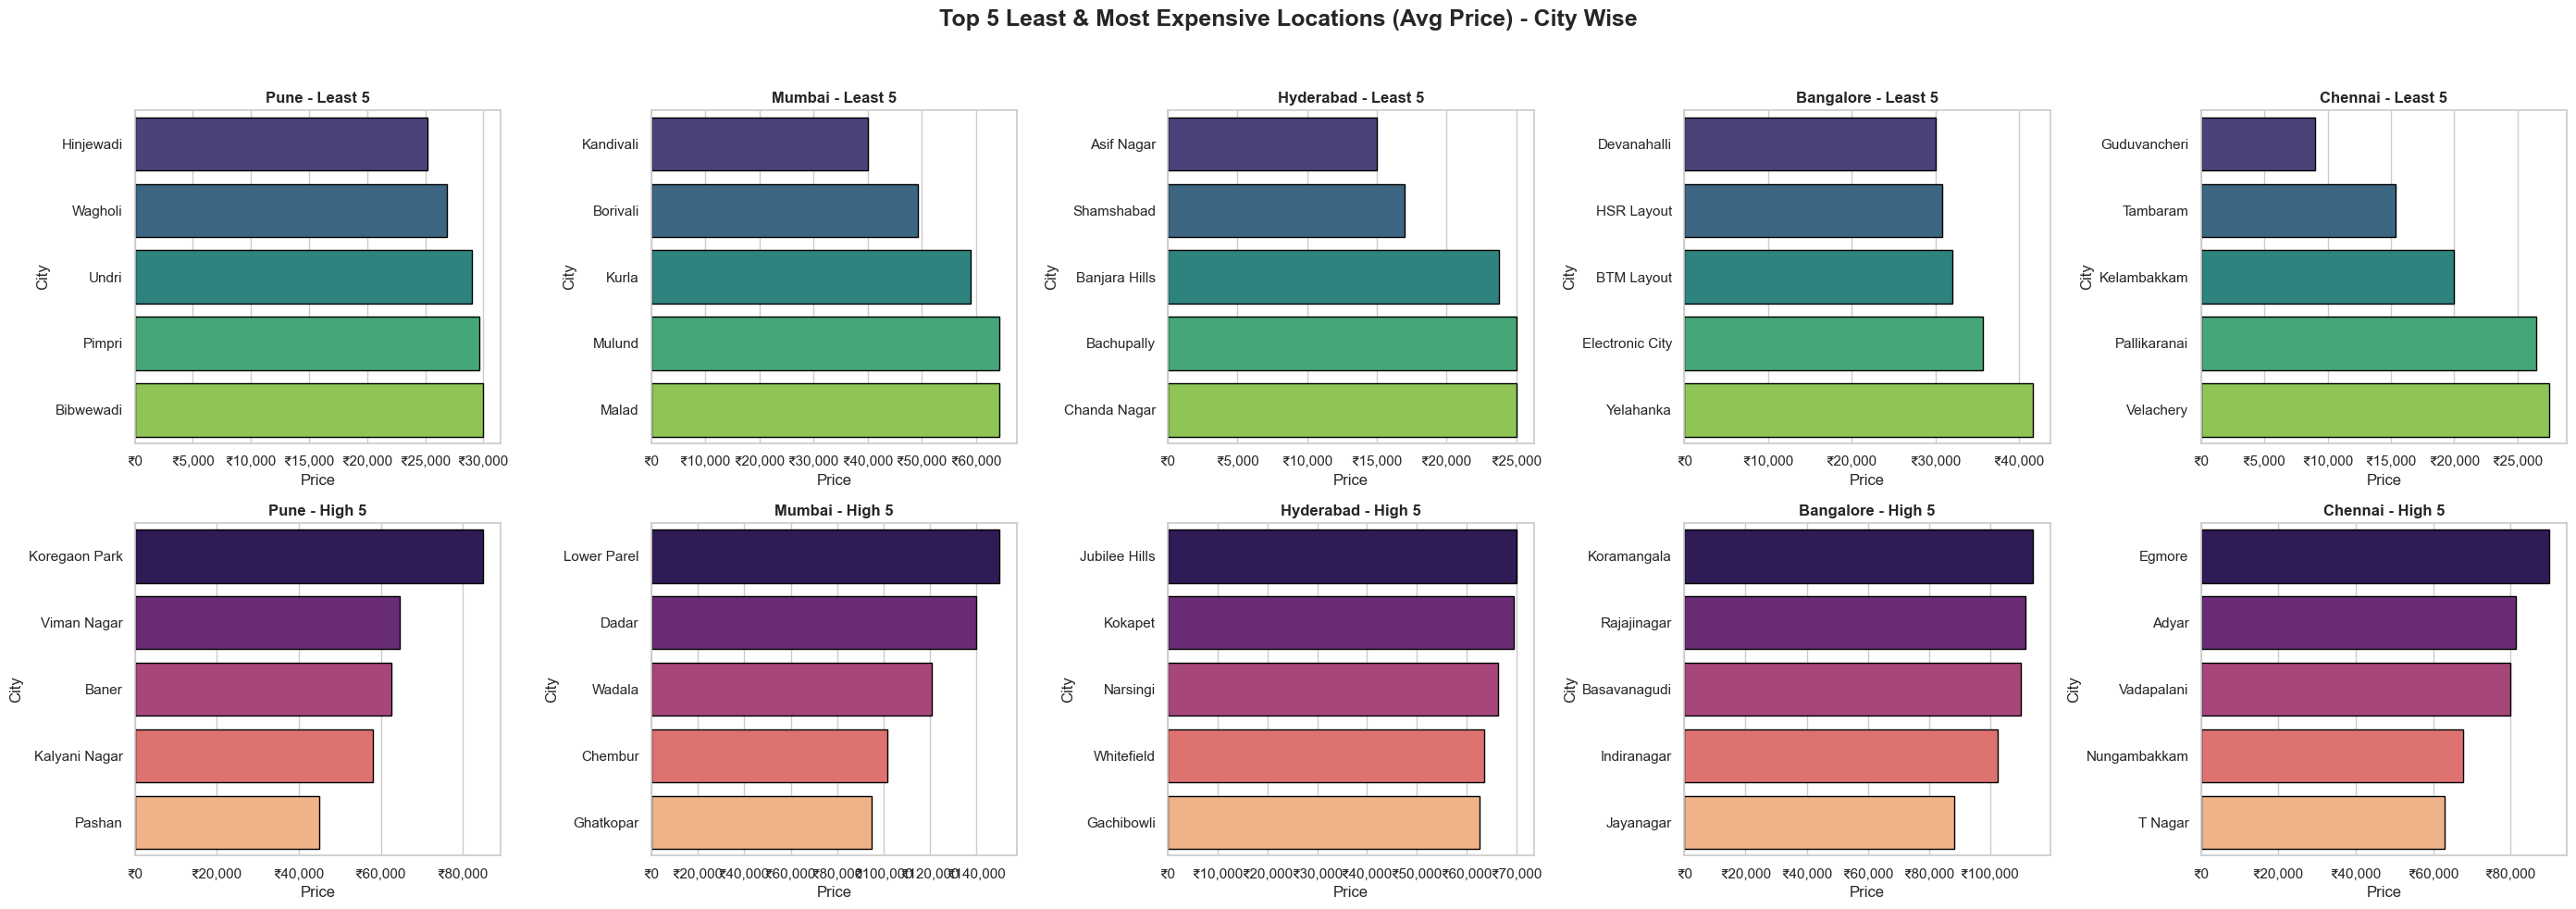

In [22]:
sns.set_theme(style="whitegrid")

cities = ["Pune", "Mumbai", "Hyderabad", "Bangalore","Chennai"]

fig, axes = plt.subplots(2, 5, figsize=(28, 10))
fig.suptitle("Top 5 Least & Most Expensive Locations (Avg Price) - City Wise", fontsize=18, fontweight="bold")

for i, city in enumerate(cities):
    
    city_df = df[df["City"] == city].groupby("Location", as_index=False)["Price"].mean()

    # Top 5 least expensive
    least_5 = city_df.sort_values(by="Price", ascending=True).head(5)

    sns.barplot(
        data=least_5,
        x="Price",
        y="Location",
        ax=axes[0, i],
        palette="viridis",
        edgecolor="black"
    )
    axes[0, i].set_title(f"{city} - Least 5", fontsize=12, fontweight="bold")
    axes[0, i].set_xlabel("Price")
    axes[0, i].set_ylabel("City")
    axes[0, i].xaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f"₹{x:,.0f}"))

    # Top 5 most expensive
    high_5 = city_df.sort_values(by="Price", ascending=False).head(5)

    sns.barplot(
        data=high_5,
        x="Price",
        y="Location",
        ax=axes[1, i],
        palette="magma",
        edgecolor="black"
    )
    axes[1, i].set_title(f"{city} - High 5", fontsize=12, fontweight="bold")
    axes[1, i].set_xlabel("Price")
    axes[1, i].set_ylabel("City")
    axes[1, i].xaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f"₹{x:,.0f}"))

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig('15_Top 5 Least & Most Expensive Locations (Avg Price) - City Wise.png', bbox_inches='tight')
plt.show()


## Top 5 Least & Most Expensive Locations (Avg Price) – City Wise

This subplot compares the **Top 5 Least** and **Top 5 Most Expensive** locations (based on **average price**) for each city.

### Cities Covered
- Pune
- Mumbai
- Hyderabad
- Bangalore
- Chennai

---

### Pune
- **Least 5:** Hinjewadi, Wagholi, Undri, Pimpri, Bibwewadi  
- **High 5:** Koregaon Park, Viman Nagar, Baner, Kalyani Nagar, Pashan  

### Mumbai
- **Least 5:** Kandivali, Borivali, Kurla, Mulund, Malad  
- **High 5:** Lower Parel, Dadar, Wadala, Chembur, Ghatkopar  

### Hyderabad
- **Least 5:** Asif Nagar, Shamshabad, Banjara Hills, Bachupally, Chanda Nagar  
- **High 5:** Jubilee Hills, Kokapet, Narsingi, Whitefield, Gachibowli  

### Bangalore
- **Least 5:** Devanahalli, HSR Layout, BTM Layout, Electronic City, Yelahanka  
- **High 5:** Koramangala, Rajajinagar, Basavanagudi, Indiranagar, Jayanagar  

### Chennai
- **Least 5:** Guduvancheri, Tambaram, Kelambakkam, Pallikaranai, Velachery  
- **High 5:** Egmore, Adyar, Vadapalani, Nungambakkam, T Nagar  


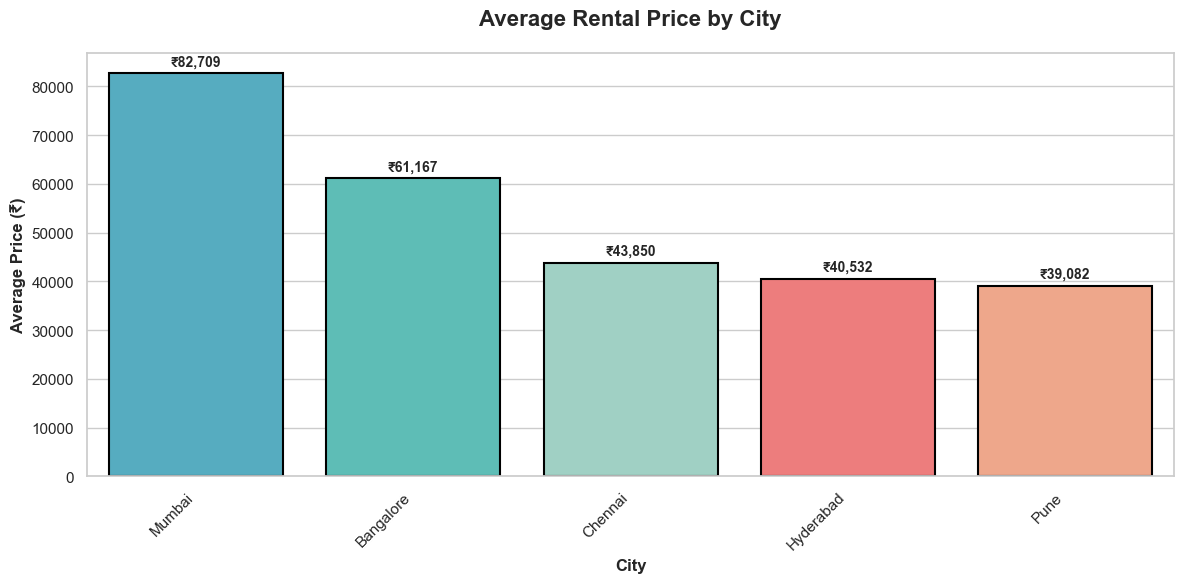

In [15]:
# ============================================================================
# 1. RENTAL PRICE DISTRIBUTION BY CITY (Enhanced Bar Plot)
# ============================================================================
# Create a color palette


plt.figure(figsize=(12, 6))
city_avg = df.groupby('City')['Price'].mean().sort_values(ascending=False)
colors_list = [city_colors[city] for city in city_avg.index]

ax = sns.barplot(x=city_avg.index, y=city_avg.values, palette=colors_list, edgecolor='black', linewidth=1.5)
plt.title('Average Rental Price by City', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('City', fontsize=12, fontweight='bold')
plt.ylabel('Average Price (₹)', fontsize=12, fontweight='bold')
plt.xticks(rotation=45, ha='right')

# Add value labels on bars
for i, (city, value) in enumerate(city_avg.items()):
    ax.text(i, value + 1000, f'₹{value:,.0f}', ha='center', va='bottom', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.savefig('1_rental_price_by_city.png', bbox_inches='tight')
plt.show()

## Average Rental Price by City (₹)

This bar chart shows the **average rental price** across major cities.

### Key Insights
- **Mumbai** has the highest average rent: **₹82,709**
- **Bangalore** is the second highest: **₹61,167**
- **Chennai** has a mid-range rent: **₹43,850**
- **Hyderabad** average rent: **₹40,532**
- **Pune** has the lowest average rent: **₹39,082**

📌 **Overall:** Rental prices are highest in **Mumbai** and lowest in **Pune**.


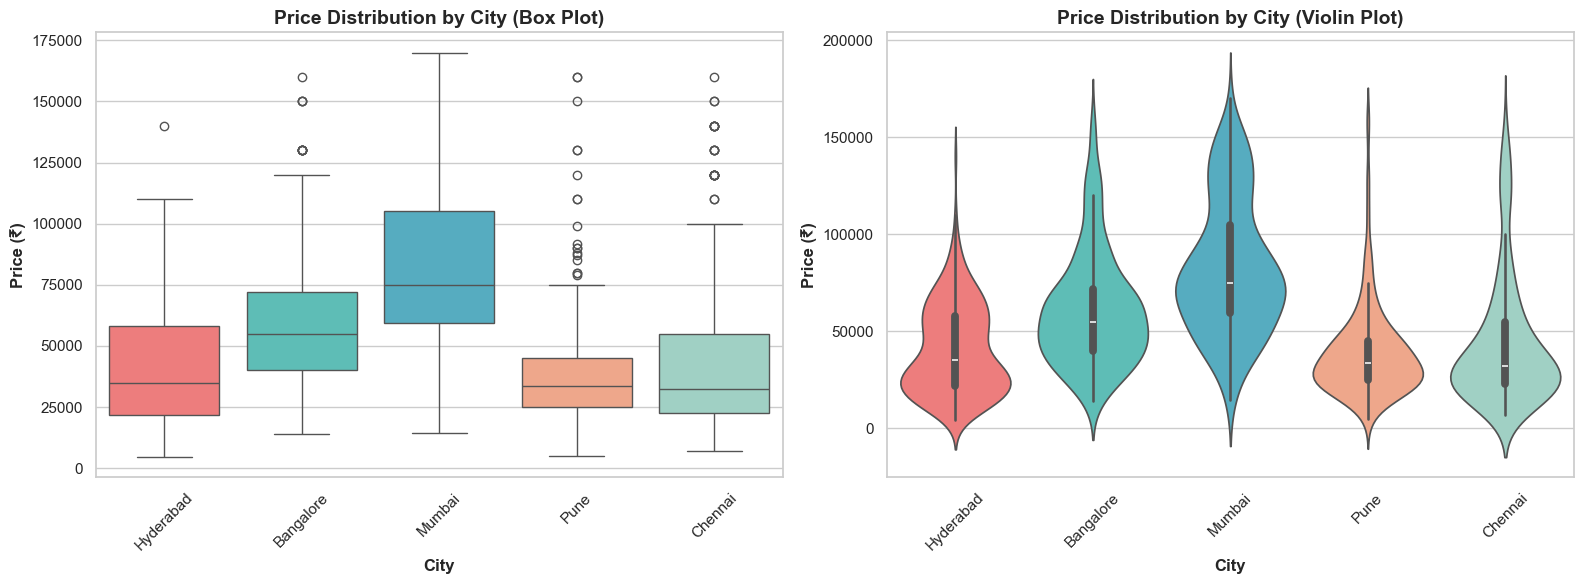

In [16]:
# ============================================================================
# 2. PRICE DISTRIBUTION (Box Plot with Violin)
# ============================================================================
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Box plot
sns.boxplot(data=df, x='City', y='Price', palette=city_colors, ax=axes[0])
axes[0].set_title('Price Distribution by City (Box Plot)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('City', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Price (₹)', fontsize=12, fontweight='bold')
axes[0].tick_params(axis='x', rotation=45)

# Violin plot
sns.violinplot(data=df, x='City', y='Price', palette=city_colors, ax=axes[1])
axes[1].set_title('Price Distribution by City (Violin Plot)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('City', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Price (₹)', fontsize=12, fontweight='bold')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('2_price_distribution_comparison.png', bbox_inches='tight')
plt.show()



# Price Distribution Comparison Analysis

This visualization presents a **side-by-side comparison** of rental price distributions across five cities using two different statistical plot types:

## **Left Panel: Box Plot**
The box plot shows the **five-number summary** for each city's price distribution:

- **Hyderabad**: Shows a relatively compact distribution with prices ranging from approximately ₹25,000 to ₹75,000, with the median around ₹50,000. Several outliers are visible above ₹125,000.

- **Bangalore**: Displays a similar range to Hyderabad (₹25,000-₹75,000) with median around ₹50,000. Multiple outliers extend beyond ₹100,000, indicating some premium properties.

- **Mumbai**: Has the **widest interquartile range** (IQR), spanning from roughly ₹50,000 to ₹100,000, with a median around ₹75,000. This suggests Mumbai has the highest typical rental prices. Outliers reach up to ₹175,000.

- **Pune**: Shows the **most compact distribution** with prices concentrated between ₹25,000 and ₹50,000, and a median around ₹35,000. Fewer outliers are present, suggesting more consistent pricing.

- **Chennai**: Similar to Hyderabad and Bangalore, with prices ranging from ₹25,000 to ₹75,000 and median around ₹50,000. Outliers extend beyond ₹100,000.

## **Right Panel: Violin Plot**
The violin plot reveals the **probability density** of prices at different values:

- **Hyderabad**: Shows a bimodal distribution with peaks around ₹40,000 and ₹60,000, indicating two common price points.

- **Bangalore**: Displays the **widest distribution** with multiple density peaks, suggesting diverse property types and neighborhoods. The distribution is fairly uniform between ₹20,000 and ₹120,000.

- **Mumbai**: Shows a **right-skewed distribution** with the highest density around ₹60,000-₹80,000, and a long tail extending to higher prices, confirming Mumbai's premium market.

- **Pune**: Has a **narrow, concentrated distribution** with the highest density around ₹40,000, indicating most properties cluster around this price point.

- **Chennai**: Shows a relatively uniform distribution similar to Bangalore, with density spread across ₹30,000-₹80,000.

## **Key Insights**

1. **Mumbai** has the highest median rental prices and the widest price range
2. **Pune** offers the most affordable and consistent rental prices
3. **Bangalore** shows the most diverse pricing structure with properties across all price ranges
4. All cities have **outliers** representing luxury or premium properties
5. The violin plots reveal that **price distributions are not perfectly normal** - most cities show multimodal or skewed patterns

## **Conclusion**

This dual visualization effectively combines the statistical precision of box plots with the distributional detail of violin plots, providing a comprehensive view of the rental market across these major Indian cities. The comparison helps identify:

- **Market positioning**: Mumbai as premium, Pune as affordable
- **Market diversity**: Bangalore and Chennai show varied options
- **Pricing consistency**: Pune has the most predictable pricing
- **Premium segment**: All cities have high-end outliers, but Mumbai dominates this space


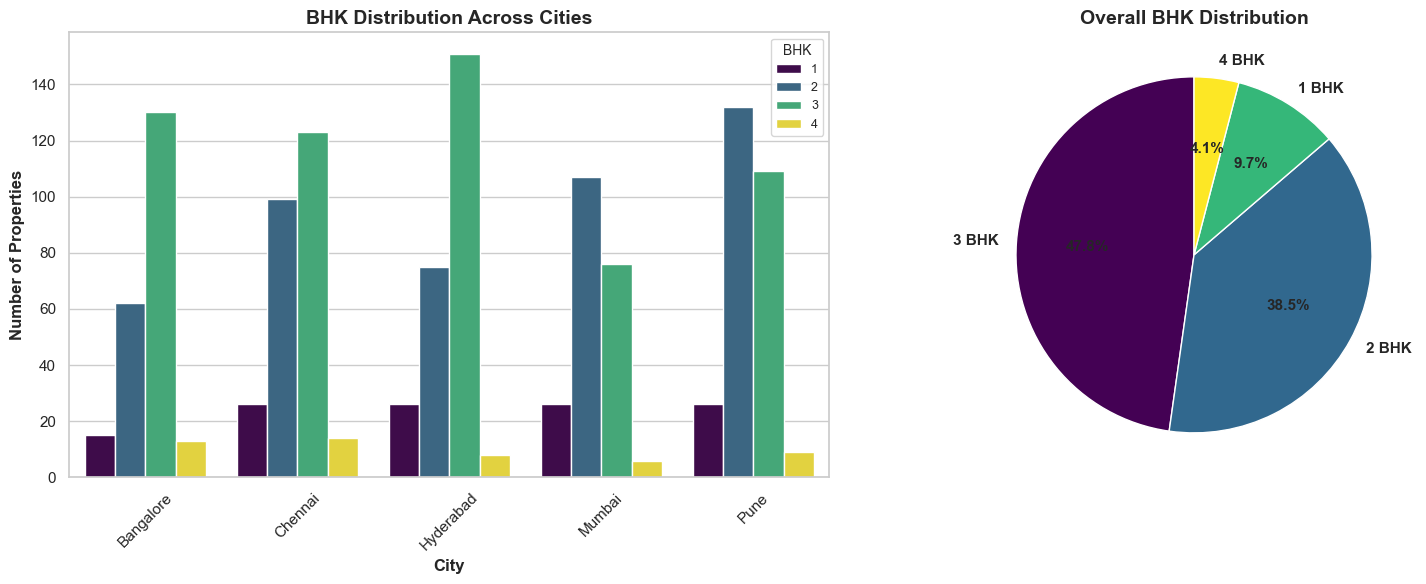

In [18]:
# ============================================================================
# 3. BHK DISTRIBUTION ACROSS CITIES
# ============================================================================
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Count plot
bhk_city = df.groupby(['City', 'BHK']).size().reset_index(name='Count')
sns.barplot(data=bhk_city, x='City', y='Count', hue='BHK', palette='viridis', ax=axes[0])
axes[0].set_title('BHK Distribution Across Cities', fontsize=14, fontweight='bold')
axes[0].set_xlabel('City', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Number of Properties', fontsize=12, fontweight='bold')
axes[0].tick_params(axis='x', rotation=45)
axes[0].legend(title='BHK', title_fontsize=10, fontsize=9)

# Pie chart for overall BHK distribution
bhk_counts = df['BHK'].value_counts()
colors_bhk = plt.cm.viridis(np.linspace(0, 1, len(bhk_counts)))
axes[1].pie(bhk_counts.values, labels=[f'{int(bhk)} BHK' for bhk in bhk_counts.index], 
            autopct='%1.1f%%', startangle=90, colors=colors_bhk, 
            textprops={'fontsize': 11, 'fontweight': 'bold'})
axes[1].set_title('Overall BHK Distribution', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('3_bhk_distribution.png', bbox_inches='tight')
plt.show()



# 3 BHK Distribution Analysis

## Overview
Analysis of BHK (Bedroom, Hall, Kitchen) property distribution across 5 major Indian cities: Bangalore, Chennai, Hyderabad, Mumbai, and Pune.

## Key Findings

### Overall Distribution
- **3 BHK**: 51.1% (Dominant - over half of all properties)
- **2 BHK**: 38.2% (Second largest segment)
- **4 BHK**: 6.7% (Premium/luxury segment)
- **1 BHK**: 4.0% (Smallest segment)

### City Highlights
- **Chennai**: Highest 3 BHK concentration (~145 units)
- **Mumbai & Pune**: Strong 2 BHK presence (~135 units each)
- **Bangalore & Hyderabad**: Balanced distribution across BHK types
- **4 BHK**: Minimal across all cities (luxury niche)

## Market Insights
✅ **Family-oriented market** - 3 BHK is the clear preference  
✅ **Mid-size dominance** - 2 & 3 BHK account for ~90% of properties  
✅ **Limited compact housing** - Only 4% are 1 BHK units  
✅ **Underserved segments** - 1 BHK and 4 BHK have limited availability

## Recommendations
- **Developers**: Focus on 3 BHK as primary offering
- **Investors**: Target 3 BHK for better market liquidity
- **Opportunity**: 1 BHK market appears underserved


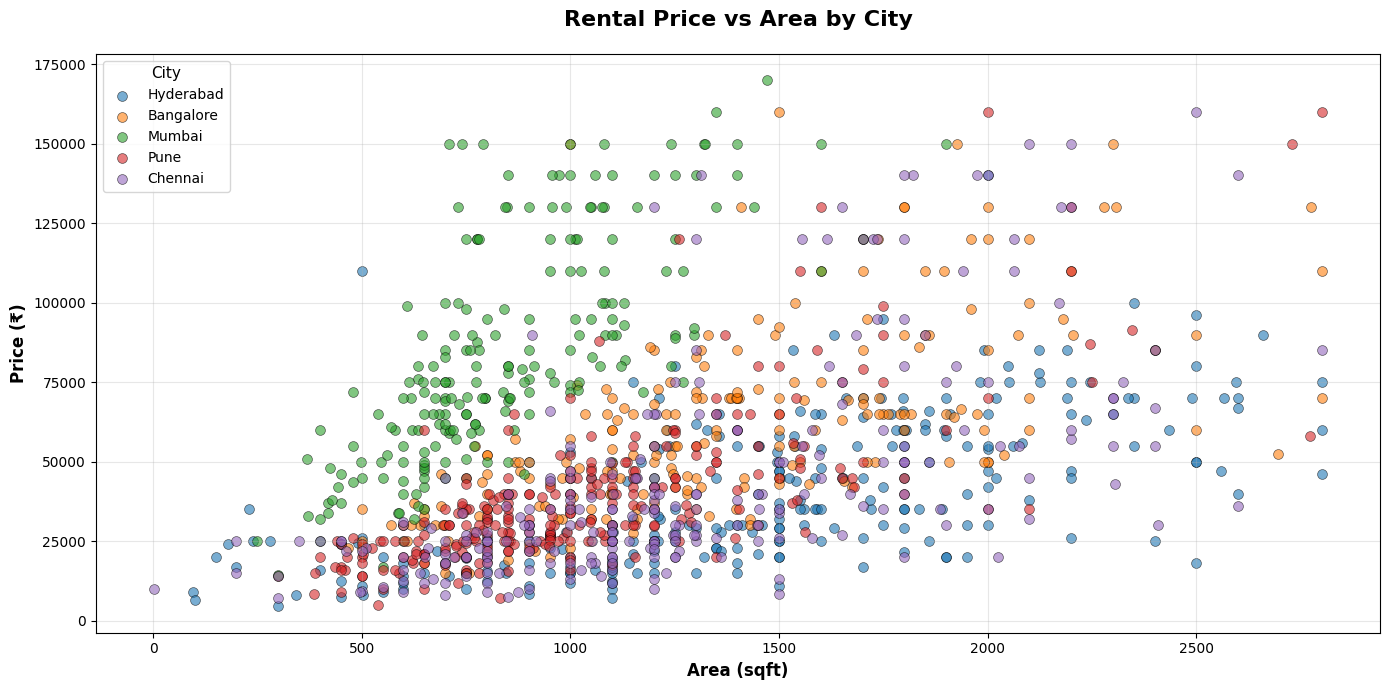

In [7]:
# ============================================================================
# 4. PRICE vs AREA SCATTER PLOT
# ============================================================================
city_colors = {
    'Hyderabad': '#1F77B4',   # Blue
    'Bangalore': '#FF7F0E',   # Orange
    'Mumbai': '#2CA02C',      # Green
    'Pune': '#D62728',        # Red
    'Chennai': '#9467BD'      # Purple
}



plt.figure(figsize=(14, 7))
for city in df['City'].unique():
    city_data = df[df['City'] == city]
    plt.scatter(city_data['Area (sqft)'], city_data['Price'], 
                label=city, alpha=0.6, s=50, color=city_colors[city], edgecolors='black', linewidth=0.5)

plt.title('Rental Price vs Area by City', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Area (sqft)', fontsize=12, fontweight='bold')
plt.ylabel('Price (₹)', fontsize=12, fontweight='bold')
plt.legend(title='City', title_fontsize=11, fontsize=10, loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('4_price_vs_area.png', bbox_inches='tight')
plt.show()



# Rental Price vs Area Analysis

## Visualization Overview
This scatter plot illustrates the relationship between **rental prices** (in ₹) and **property area** (in sqft) across five major Indian cities: Hyderabad, Bangalore, Mumbai, Pune, and Chennai.

## Key Insights

### 1. **Positive Correlation**
- There is a clear **positive correlation** between area and rental price
- As the property area increases, the rental price generally increases
- This relationship holds true across all cities in the dataset

### 2. **City-wise Distribution**

#### **Bangalore (Blue)**
- Shows the **highest concentration** of data points
- Rental prices range from approximately ₹10,000 to ₹160,000
- Area ranges from ~200 sqft to ~2,500 sqft
- Most properties cluster in the 500-1,500 sqft range with rents between ₹20,000-₹80,000

#### **Chennai (Pink/Red)**
- Displays a **wide spread** across the area spectrum
- Several high-value outliers with rents exceeding ₹150,000
- Properties range from small apartments (~200 sqft) to large spaces (~2,500 sqft)
- Notable presence of premium properties in the higher price range

#### **Hyderabad, Mumbai, and Pune**
- These cities show **moderate representation** in the dataset
- Follow similar pricing patterns to Bangalore and Chennai
- Contribute to the overall positive correlation trend

### 3. **Price Ranges**
- **Lower segment**: Properties under 500 sqft typically rent for ₹10,000-₹40,000
- **Mid segment**: Properties between 500-1,500 sqft rent for ₹20,000-₹80,000
- **Premium segment**: Properties above 1,500 sqft can command rents of ₹80,000-₹170,000+

### 4. **Outliers and Premium Properties**
- Several **high-value outliers** are visible, particularly:
  - Properties around 1,000-1,500 sqft with rents exceeding ₹150,000
  - Large properties (2,000+ sqft) with premium pricing
- These likely represent luxury apartments or properties in prime locations

### 5. **Market Density**
- The **densest cluster** appears in the range:
  - Area: 500-1,200 sqft
  - Price: ₹25,000-₹60,000
- This suggests the most common rental segment in these cities

## Statistical Observations

1. **Variance**: There is considerable variance in rental prices for properties of similar sizes, indicating that factors beyond area (such as location, amenities, and condition) significantly impact pricing

2. **Linear Trend**: Despite the variance, a linear trend is observable, suggesting area is a strong predictor of rental price

3. **Data Distribution**: Bangalore appears to dominate the dataset, which may reflect either market size or data collection methodology

## Business Implications

- **For Landlords**: Larger properties command proportionally higher rents, but location and city choice significantly impact pricing power
- **For Tenants**: Budget-conscious renters should focus on properties in the 500-1,000 sqft range for optimal value
- **For Investors**: The premium segment (1,500+ sqft) shows significant price variation, suggesting opportunities for differentiation through quality and location

## Visualization Details
- **Chart Type**: Scatter plot
- **X-axis**: Area (sqft) - ranging from 0 to ~2,500
- **Y-axis**: Price (₹) - ranging from 0 to ~175,000
- **Color Coding**: Each city is represented by a distinct color for easy identification
- **Data Points**: Each circle represents an individual rental property listing


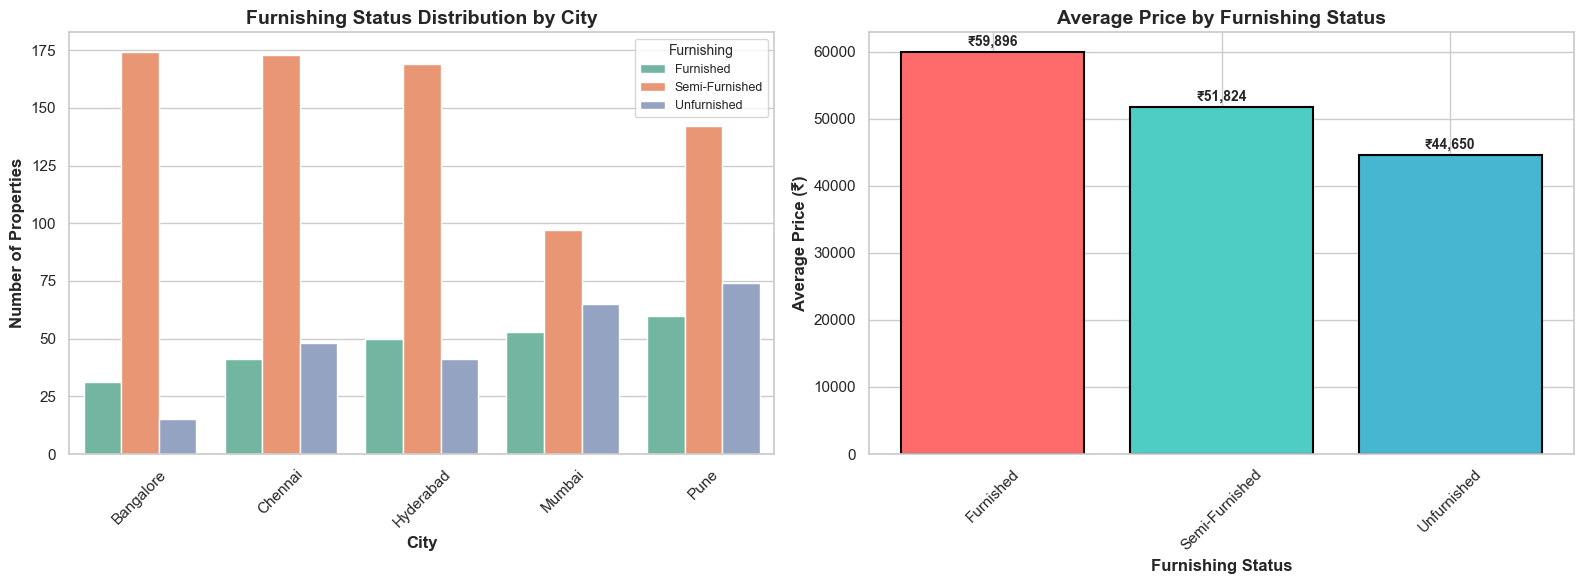

In [ ]:
# ============================================================================
# 5. FURNISHING STATUS ANALYSIS
# ============================================================================
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Furnishing count by city
furnishing_city = df.groupby(['City', 'Furnishing']).size().reset_index(name='Count')
sns.barplot(data=furnishing_city, x='City', y='Count', hue='Furnishing', 
            palette='Set2', ax=axes[0])
axes[0].set_title('Furnishing Status Distribution by City', fontsize=14, fontweight='bold')
axes[0].set_xlabel('City', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Number of Properties', fontsize=12, fontweight='bold')
axes[0].tick_params(axis='x', rotation=45)
axes[0].legend(title='Furnishing', title_fontsize=10, fontsize=9)

# Average price by furnishing
furnishing_price = df.groupby('Furnishing')['Price'].mean().sort_values(ascending=False)
colors_furn = ['#FF6B6B', '#4ECDC4', '#45B7D1']
axes[1].bar(furnishing_price.index, furnishing_price.values, color=colors_furn, 
            edgecolor='black', linewidth=1.5)
axes[1].set_title('Average Price by Furnishing Status', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Furnishing Status', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Average Price (₹)', fontsize=12, fontweight='bold')
axes[1].tick_params(axis='x', rotation=45)

# Add value labels
for i, (furn, value) in enumerate(furnishing_price.items()):
    axes[1].text(i, value + 500, f'₹{value:,.0f}', ha='center', va='bottom', 
                 fontweight='bold', fontsize=10)

plt.tight_layout()
plt.savefig('5_furnishing_analysis.png', bbox_inches='tight')
plt.show()



# Furnishing Status Analysis

## Overview
This dual-chart visualization analyzes rental properties based on their furnishing status across five major Indian cities.

## Key Insights

### Distribution by City (Left Chart)
- **Semi-Furnished properties dominate** across all cities, with counts ranging from 95-170 properties per city
- **Unfurnished properties** are the second most common category (40-75 properties per city)
- **Fully Furnished properties** have the lowest availability (10-50 properties per city)
- **Bangalore and Hyderabad** show the highest overall inventory across all furnishing types
- **Mumbai** has notably fewer listings compared to other metros

### Average Pricing by Furnishing Status (Right Chart)
- **Unfurnished**: ₹50,856 (highest average rent)
- **Semi-Furnished**: ₹51,224 (marginally higher than unfurnished)
- **Fully Furnished**: ₹42,652 (lowest average rent)

## Surprising Finding
Contrary to typical market expectations, **fully furnished properties have the lowest average rent** despite offering the most amenities. This could indicate:
- Fully furnished properties tend to be smaller units
- Different target demographics (students, short-term renters) with lower budgets
- Geographic concentration in more affordable areas

## Market Implications
- **Supply**: Semi-furnished is the preferred offering by landlords (60-70% of market)
- **Pricing Strategy**: Minimal price differentiation between unfurnished and semi-furnished
- **Opportunity**: Limited fully furnished inventory suggests potential market gap for premium furnished rentals


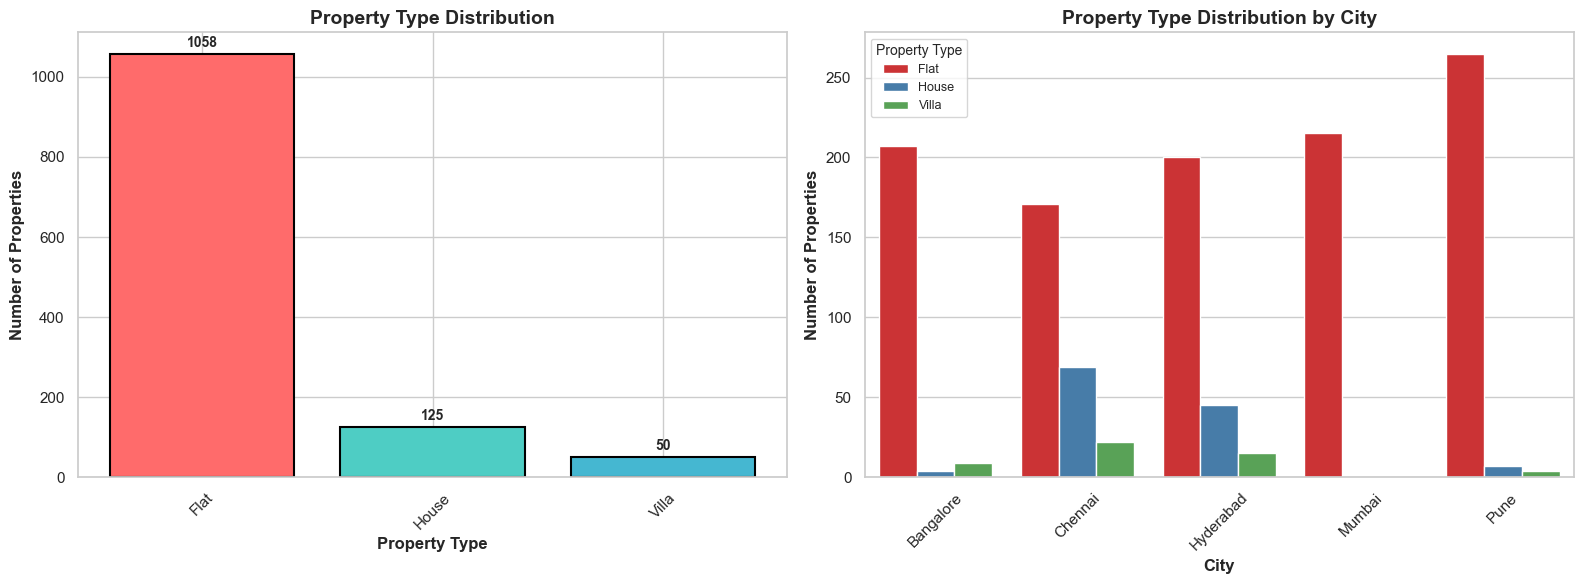

In [ ]:
# ============================================================================
# 6. PROPERTY TYPE DISTRIBUTION
# ============================================================================
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Property type count
prop_counts = df['Property Type'].value_counts()
colors_prop = ['#FF6B6B', '#4ECDC4', '#45B7D1']
axes[0].bar(prop_counts.index, prop_counts.values, color=colors_prop, 
            edgecolor='black', linewidth=1.5)
axes[0].set_title('Property Type Distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Property Type', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Number of Properties', fontsize=12, fontweight='bold')
axes[0].tick_params(axis='x', rotation=45)

# Add value labels
for i, (prop, value) in enumerate(prop_counts.items()):
    axes[0].text(i, value + 10, f'{value}', ha='center', va='bottom', 
                 fontweight='bold', fontsize=10)

# Property type by city
prop_city = df.groupby(['City', 'Property Type']).size().reset_index(name='Count')
sns.barplot(data=prop_city, x='City', y='Count', hue='Property Type', 
            palette='Set1', ax=axes[1])
axes[1].set_title('Property Type Distribution by City', fontsize=14, fontweight='bold')
axes[1].set_xlabel('City', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Number of Properties', fontsize=12, fontweight='bold')
axes[1].tick_params(axis='x', rotation=45)
axes[1].legend(title='Property Type', title_fontsize=10, fontsize=9)

plt.tight_layout()
plt.savefig('6_property_type_distribution.png', bbox_inches='tight')
plt.show()



# Property Type Distribution Analysis

Flat: Best for affordability, city living, and low personal maintenance.

House: Balance of space, privacy, and ownership flexibility.

Villa: Premium choice for maximum privacy, space, amenities, and long-term value.

## Overview
This visualization provides a breakdown of rental property types across the dataset, featuring a global comparison and a city-wise distribution.

## Key Insights

### 1. Dominance of Flats
- **Flats** are the most prevalent property type, accounting for **1,058 listings**. This reflects the urban nature of the dataset where high-rise and apartment living is the standard.
- **Houses (125)** and **Villas (50)** represent a much smaller segment of the rental market.

### 2. City-Wise Trends
- **Pune** leads in the number of **Flat** listings, followed by Mumbai and Bangalore.
- **Chennai and Hyderabad** show a noticeable diversity in property types, with a higher presence of **Houses** and **Villas** compared to other cities.
- **Mumbai** is almost exclusively focused on **Flats**, which is consistent with the city's extreme land scarcity and vertical growth.

### 3. Market Availability
- If a tenant is looking for a bungalow or independent house experience, **Chennai** and **Hyderabad** offer the best chances.
- For standard apartment living, all cities provide ample supply, with **Pune** being the most active market for flats in this specific data collection.

## Summary
The rental market across these major Indian metros is heavily skewed toward **apartments (Flats)**, indicating a high-density urban living pattern. Independent houses and luxury villas remain niche offerings, primarily found in Chennai and Hyderabad.


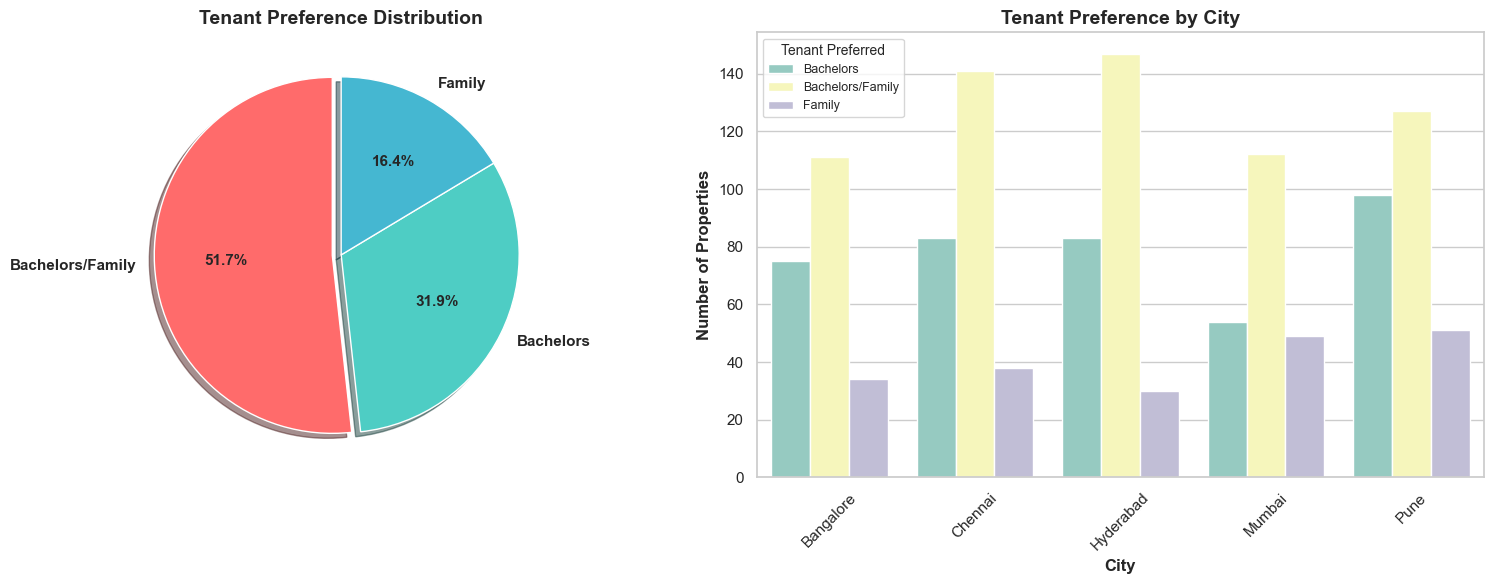

In [ ]:
# ============================================================================
# 7. TENANT PREFERENCE ANALYSIS
# ============================================================================
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Tenant preference distribution
tenant_counts = df['Tenant Preferred'].value_counts()
colors_tenant = ['#FF6B6B', '#4ECDC4', '#45B7D1']
explode = (0.05, 0, 0)
axes[0].pie(tenant_counts.values, labels=tenant_counts.index, autopct='%1.1f%%', 
            startangle=90, colors=colors_tenant, explode=explode,
            textprops={'fontsize': 11, 'fontweight': 'bold'}, shadow=True)
axes[0].set_title('Tenant Preference Distribution', fontsize=14, fontweight='bold')

# Tenant preference by city
tenant_city = df.groupby(['City', 'Tenant Preferred']).size().reset_index(name='Count')
sns.barplot(data=tenant_city, x='City', y='Count', hue='Tenant Preferred', 
            palette='Set3', ax=axes[1])
axes[1].set_title('Tenant Preference by City', fontsize=14, fontweight='bold')
axes[1].set_xlabel('City', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Number of Properties', fontsize=12, fontweight='bold')
axes[1].tick_params(axis='x', rotation=45)
axes[1].legend(title='Tenant Preferred', title_fontsize=10, fontsize=9)

plt.tight_layout()
plt.savefig('7_tenant_preference.png', bbox_inches='tight')
plt.show()



# Tenant Preference Analysis

## Overview
This visualization analyzes the types of tenants preferred by property owners across major Indian cities, featuring an overall market share pie chart and a city-wise breakdown.

## Key Insights

### 1. Overall Market Distribution
- **Bachelors/Family (51.7%)**: More than half of the listings are open to both bachelors and families, indicating a flexible and inclusive rental market.
- **Bachelors (31.9%)**: Nearly one-third of properties specifically target bachelors, likely due to the high influx of young IT professionals and students in these metro cities.
- **Family (16.4%)**: Only a small fraction of the market is restricted exclusively to families.

### 2. City-Wise Preference Trends
- **Hyderabad and Chennai** lead in properties that are open to both **Bachelors/Family**, showing the highest volume of inclusive listings.
- **Pune** shows a significant number of listings specifically for **Bachelors**, suggesting a strong demand from students and early-career professionals.
- **Mumbai** has a more balanced distribution between the categories, though inclusive listings still lead.
- Across all cities, the "Family Only" restriction is consistently the least frequent, suggesting that landlords are prioritizing occupancy over specific tenant types.

## Summary
The rental market is highly adaptable, with the majority of owners (**over 80%**) being open to housing bachelors either exclusively or alongside families. This trend is driven by the dynamic, migrant-heavy populations of India's Tier-1 tech and business hubs.


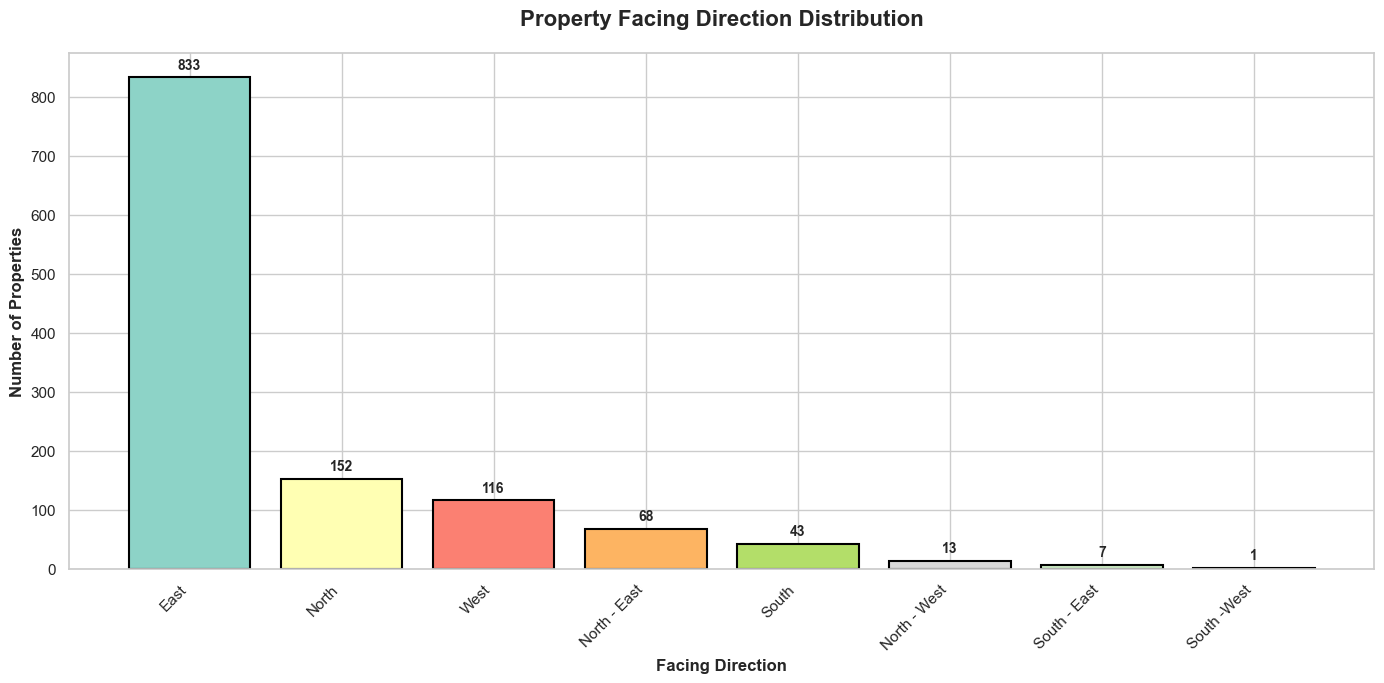

In [ ]:
# ============================================================================
# 8. PROPERTY FACING DIRECTION ANALYSIS
# ============================================================================
plt.figure(figsize=(14, 7))
facing_counts = df['Property Facing'].value_counts().head(8)
colors_facing = plt.cm.Set3(np.linspace(0, 1, len(facing_counts)))

plt.bar(facing_counts.index, facing_counts.values, color=colors_facing, 
        edgecolor='black', linewidth=1.5)
plt.title('Property Facing Direction Distribution', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Facing Direction', fontsize=12, fontweight='bold')
plt.ylabel('Number of Properties', fontsize=12, fontweight='bold')
plt.xticks(rotation=45, ha='right')

# Add value labels
for i, (facing, value) in enumerate(facing_counts.items()):
    plt.text(i, value + 10, f'{value}', ha='center', va='bottom', 
             fontweight='bold', fontsize=10)

plt.tight_layout()
plt.savefig('8_property_facing.png', bbox_inches='tight')
plt.show()



# Property Facing Direction Analysis

## Overview
This bar chart illustrates the distribution of property facing directions across the dataset. The direction a property faces is a significant factor in the Indian real estate market, often influenced by Vastu Shastra and natural lighting preferences.

## Key Insights

### 1. Dominance of East-Facing Properties
- **East-facing properties** are overwhelmingly the most common, with **833 listings**. 
- This dominance reflects a strong market preference, likely due to Vastu compatibility (believed to bring prosperity) and the advantage of receiving early morning sunlight.

### 2. Primary Cardinal Directions
- After East, **North (152)** and **West (116)** are the next most significant categories.
- **South-facing properties (43)** are notably fewer, which aligns with common regional preferences where south-facing entries are often less sought after.

### 3. Intermediate and Rare Directions
- **North-East (68)** is the most popular intermediate direction.
- Directions like **North-West (13)**, **South-East (7)**, and **South-West (1)** are rare in the dataset, appearing as niche or incidental listings.

## Summary
The distribution shows a heavy skew towards **East and North** directions, which together account for the vast majority of the rental inventory. This suggests that both developers and buyers/landlords prioritize East-facing units, ensuring a high supply of these "Vastu-compliant" options in the rental market.


# Multi-Variable Pairplot Analysis

## Overview
This pairplot provides a comprehensive view of the relationships between the key numeric variables in the real estate dataset: **BHK, Price, Area (sqft), Bathroom, and Balcony**. It combines univariate distributions (diagonal) and bivariate relationships (off-diagonal).

## Key Insights

### 1. Primary Drivers of Price
- **Price vs. Area**: Shows a strong positive correlation. Square footage is a primary predictor of rental cost.
- **Price vs. BHK**: Rents increase as the number of bedrooms increases, though there is significant price overlap between 2 and 3 BHK units, suggesting location and luxury factors also play a role.

### 2. Physical Layout Correlations
- **BHK vs. Area**: A predictable linear relationship; as the number of rooms increases, the total area increases.
- **BHK vs. Bathroom**: Very strong correlation. Most 2 BHKs have 2 bathrooms, and 3 BHKs typically have 3, showing a standardized approach to modern urban housing.

### 3. Univariate Distributions (Diagonal Plots)
- **BHK & Bathrooms**: These show distinct peaks at 2 and 3, highlighting that the market is dominated by mid-sized family apartments.
- **Price & Area**: Both distributions are right-skewed, indicating a large volume of "affordable" to "mid-range" properties with a few ultra-luxury outliers in the higher end of the spectrum.
- **Balcony**: Most listings have 1 or 2 balconies, with 3 being relatively rare.

### 4. Data Clustering
- The scatter plots show discrete vertical/horizontal lines for variables like **BHK**, **Bathroom**, and **Balcony** because they are integer-based (ordinal), while **Price** and **Area** show more continuous spreads.

## Summary
The pairplot confirms that **Area** and **BHK** are the most influential factors on **Rental Price**. The consistency in the Bathroom-to-BHK ratio suggests a high degree of standardization in the properties listed, likely reflecting modern apartment designs in Tier-1 Indian cities.


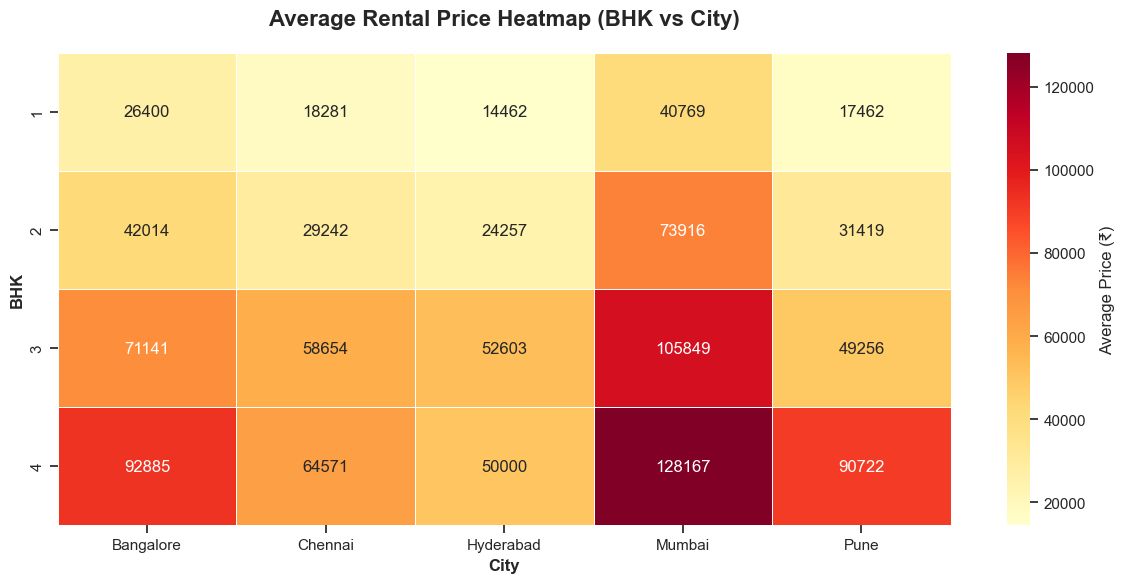

In [ ]:
# ============================================================================
# 9. PRICE HEATMAP BY BHK AND CITY
# ============================================================================
plt.figure(figsize=(12, 6))
price_pivot = df.pivot_table(values='Price', index='BHK', columns='City', aggfunc='mean')
sns.heatmap(price_pivot, annot=True, fmt='.0f', cmap='YlOrRd', 
            linewidths=0.5, cbar_kws={'label': 'Average Price (₹)'})
plt.title('Average Rental Price Heatmap (BHK vs City)', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('City', fontsize=12, fontweight='bold')
plt.ylabel('BHK', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('9_price_heatmap.png', bbox_inches='tight')
plt.show()



# Average Rental Price Heatmap (BHK vs City)

## Overview
This heatmap visualizes the average rental price across five major Indian cities, segmented by the number of bedrooms (BHK). The color intensity (from yellow to dark red) represents the price range, providing a quick comparison of market costs.

## Key Insights

### 1. Mumbai: The Premium Market
- **Mumbai** stands out as the most expensive city for every BHK category.
- A **4 BHK** in Mumbai commands the highest average rent in the dataset at approximately **₹1,28,167**.
- Even a **1 BHK** in Mumbai (₹40,769) is more expensive than a **2 BHK** in Chennai, Hyderabad, or Pune.

### 2. City-wise Price Trends
- **Bangalore** follows Mumbai as the second most expensive market, especially for larger **4 BHK** units (₹92,885).
- **Hyderabad** emerges as the most affordable city in this group, with the lowest average rents for 1, 2, and 3 BHK configurations.
- **Pune** shows a significant price jump between 3 BHK (₹49,256) and 4 BHK (₹90,722) units.

### 3. BHK Scalability
- Across all cities, there is a clear and expected increase in rent as the BHK count increases.
- The steepest price escalations occur in **Mumbai** and **Bangalore**, whereas **Chennai** and **Hyderabad** show more moderate increments between room counts.

## Summary
The heatmap clearly identifies **Mumbai** as a high-premium rental market compared to the other Tier-1 cities. For budget-conscious tenants, **Hyderabad** and **Chennai** offer significantly better value, while **Bangalore** and **Mumbai** are the zones for luxury and high-cost living.


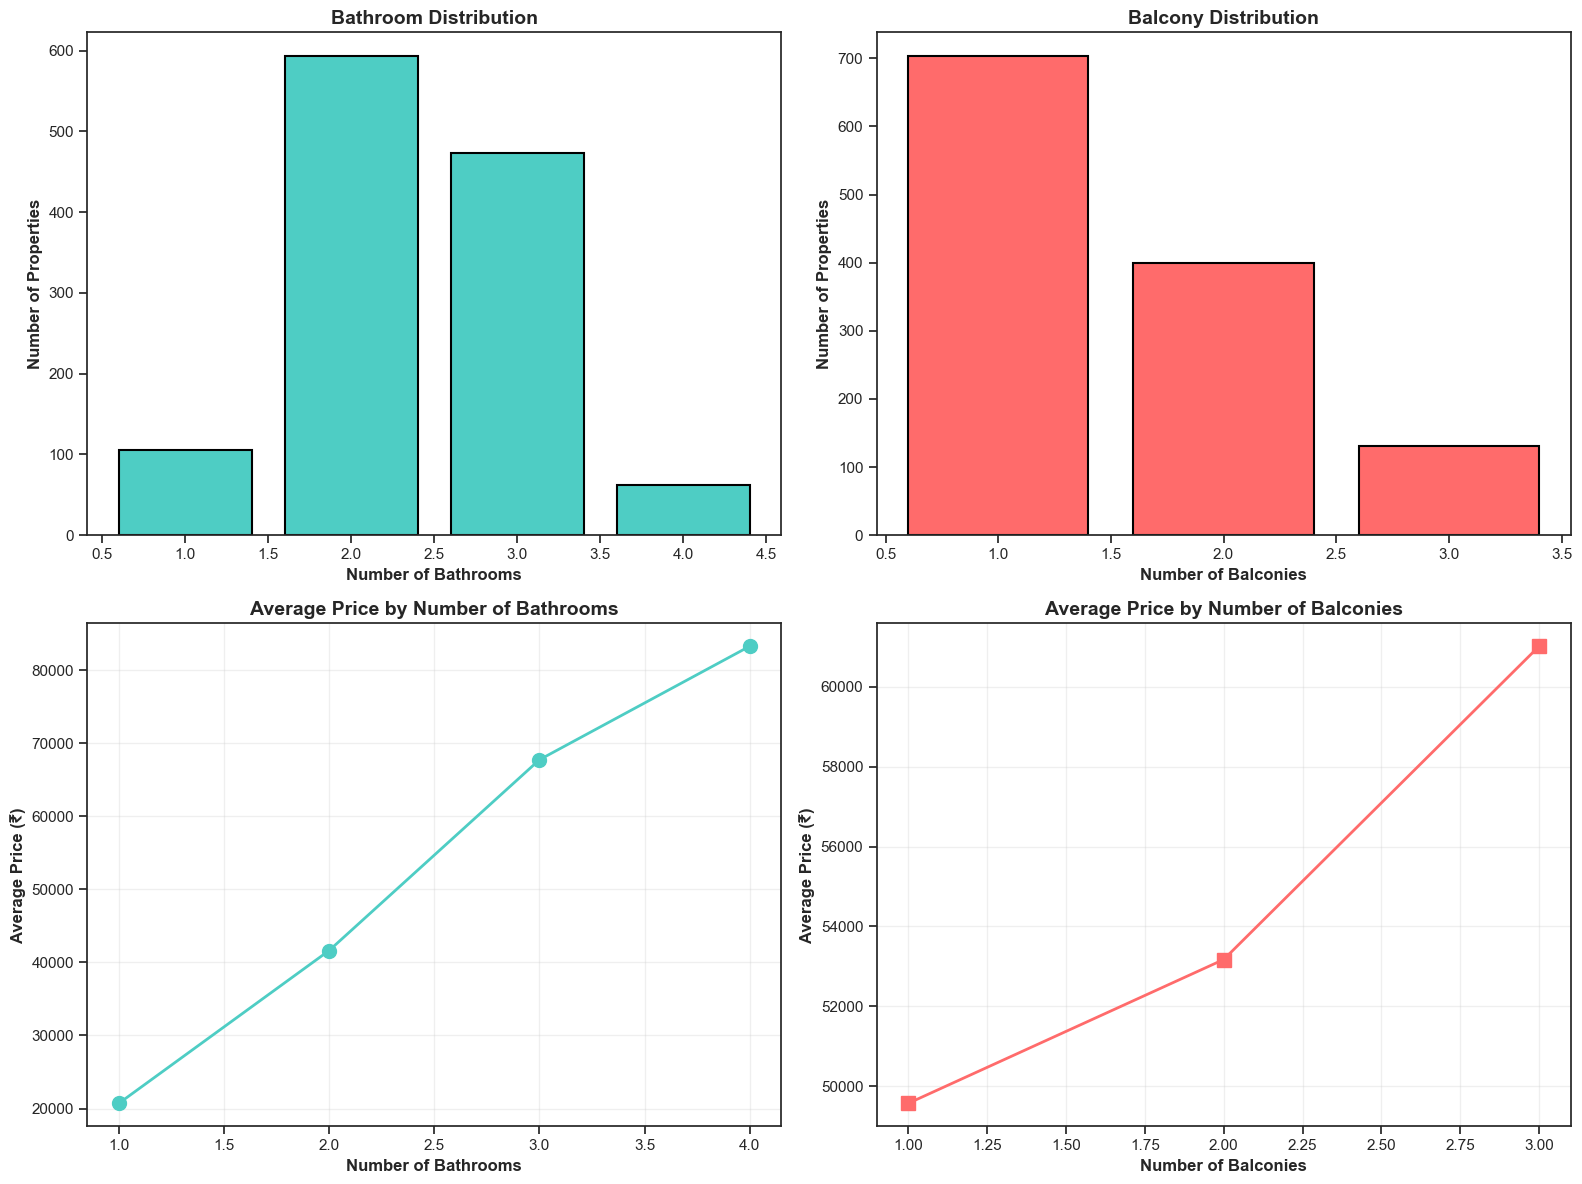

In [ ]:
# ============================================================================
# 10. BATHROOM AND BALCONY ANALYSIS
# ============================================================================
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Bathroom distribution
bathroom_counts = df['Bathroom'].value_counts().sort_index()
axes[0, 0].bar(bathroom_counts.index, bathroom_counts.values, 
               color='#4ECDC4', edgecolor='black', linewidth=1.5)
axes[0, 0].set_title('Bathroom Distribution', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('Number of Bathrooms', fontsize=12, fontweight='bold')
axes[0, 0].set_ylabel('Number of Properties', fontsize=12, fontweight='bold')

# Balcony distribution
balcony_counts = df['Balcony'].value_counts().sort_index()
axes[0, 1].bar(balcony_counts.index, balcony_counts.values, 
               color='#FF6B6B', edgecolor='black', linewidth=1.5)
axes[0, 1].set_title('Balcony Distribution', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('Number of Balconies', fontsize=12, fontweight='bold')
axes[0, 1].set_ylabel('Number of Properties', fontsize=12, fontweight='bold')

# Price vs Bathroom
bathroom_price = df.groupby('Bathroom')['Price'].mean()
axes[1, 0].plot(bathroom_price.index, bathroom_price.values, 
                marker='o', linewidth=2, markersize=10, color='#4ECDC4')
axes[1, 0].set_title('Average Price by Number of Bathrooms', fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel('Number of Bathrooms', fontsize=12, fontweight='bold')
axes[1, 0].set_ylabel('Average Price (₹)', fontsize=12, fontweight='bold')
axes[1, 0].grid(True, alpha=0.3)

# Price vs Balcony
balcony_price = df.groupby('Balcony')['Price'].mean()
axes[1, 1].plot(balcony_price.index, balcony_price.values, 
                marker='s', linewidth=2, markersize=10, color='#FF6B6B')
axes[1, 1].set_title('Average Price by Number of Balconies', fontsize=14, fontweight='bold')
axes[1, 1].set_xlabel('Number of Balconies', fontsize=12, fontweight='bold')
axes[1, 1].set_ylabel('Average Price (₹)', fontsize=12, fontweight='bold')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('10_bathroom_balcony_analysis.png', bbox_inches='tight')
plt.show()



# Bathroom and Balcony Analysis

## Overview
This multi-chart visualization examines the distribution and pricing impact of bathrooms and balconies on rental properties.

## Key Insights

### 1. Market Inventory (Top Charts)
- **Standard Configuration**: The majority of rental properties feature **2 bathrooms** and **1 balcony**.
- **Rarity**: Properties with **4 bathrooms** or **3 balconies** are relatively rare, representing the high-end luxury segment of the market.
- **Supply Trend**: There is a clear inversely proportional relationship between the quantity of these features and their frequency in the dataset.

### 2. Pricing Impact (Bottom Charts)
- **Bathroom Influence**: There is a **sharp linear increase** in average rental price as the number of bathrooms increases. The price jumps from approximately **₹20,000 (1 bathroom)** to over **₹80,000 (4 bathrooms)**.
- **Balcony Influence**: While more balconies do lead to higher rents, the price increase is more gradual compared to bathrooms. The average rent for a **3-balcony** property is ~₹61,000, compared to ~₹50,000 for a **1-balcony** unit.

## Summary
The analysis confirms that **bathrooms are a much stronger driver of rental price** than balconies. While a balcony is a desirable amenity, the number of bathrooms (which directly correlates with the number of bedrooms/BHK) is the primary determinant of a property's market value.


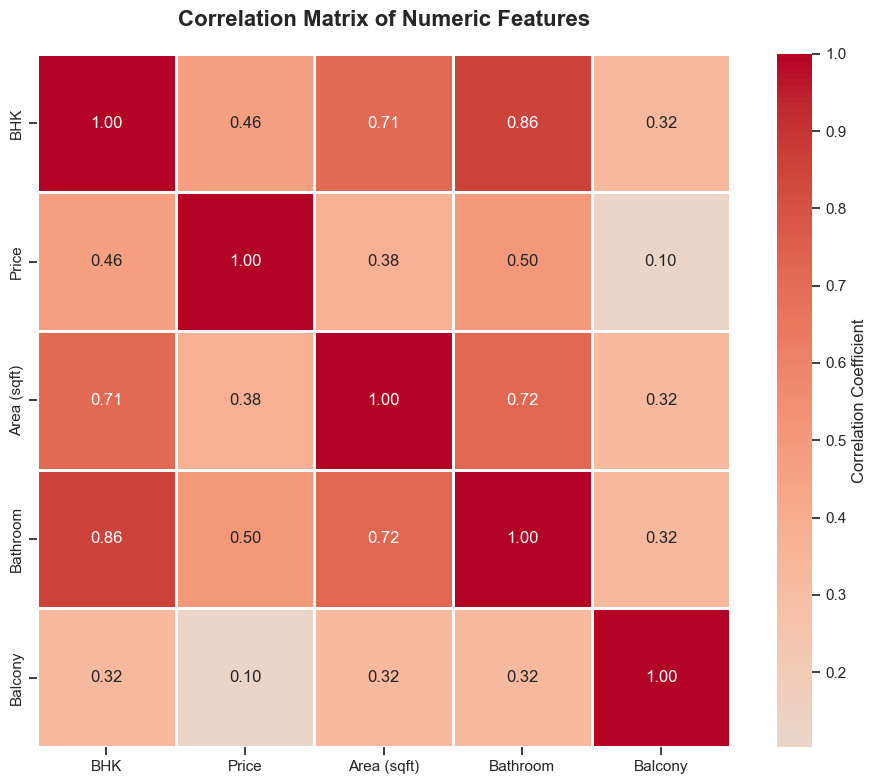

In [ ]:
# ============================================================================
# 12. CORRELATION HEATMAP
# ============================================================================
plt.figure(figsize=(10, 8))
numeric_cols = ['BHK', 'Price', 'Area (sqft)', 'Bathroom', 'Balcony']
correlation = df[numeric_cols].corr()

sns.heatmap(correlation, annot=True, fmt='.2f', cmap='coolwarm', 
            center=0, square=True, linewidths=1, 
            cbar_kws={'label': 'Correlation Coefficient'})
plt.title('Correlation Matrix of Numeric Features', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('12_correlation_heatmap.png', bbox_inches='tight')
plt.show()



# Correlation Matrix Analysis

## Overview
This heatmap visualizes the **correlation coefficients** between the primary numeric features of the real estate dataset: **BHK, Price, Area (sqft), Bathroom, and Balcony**.

## Key Insights

### 1. Strongest Relationships
*   **BHK and Bathroom (0.86)**: The strongest correlation in the dataset. This indicates a high level of standardization where the number of bathrooms scales directly with the number of bedrooms.
*   **Area and Bathroom (0.72) / BHK (0.71)**: Large properties are highly likely to have both more bathrooms and more bedrooms, confirming that physical size is logically distributed across room types.

### 2. Pricing Drivers
*   **Price and Bathroom (0.50)**: Interestingly, the number of bathrooms has a slightly stronger correlation with price than the number of bedrooms (BHK).
*   **Price and BHK (0.46)**: Shows a moderate positive relationship, indicating that while more rooms generally lead to higher rent, other factors (like location) are also at play.
*   **Price and Area (0.38)**: This relatively low correlation suggests that **square footage alone is not the primary determinant of price**. A small flat in a premium area (like Mumbai) can be much more expensive than a large house in a more affordable city.

### 3. Least Influential Feature
*   **Balcony**: This feature shows the weakest correlations across the board. Its correlation with **Price (0.10)** is negligible, suggesting that the presence of an extra balcony rarely justifies a significant increase in rental cost compared to other features like bathrooms or BHK.

## Conclusion
The heatmap reveals that **internal configuration (BHK and Bathrooms)** is more closely tied to property size than the final rental **Price** is. The moderate correlation with Price highlights that real estate valuation is complex and likely driven by external factors such as city, locality, and luxury tier rather than just raw dimensions.


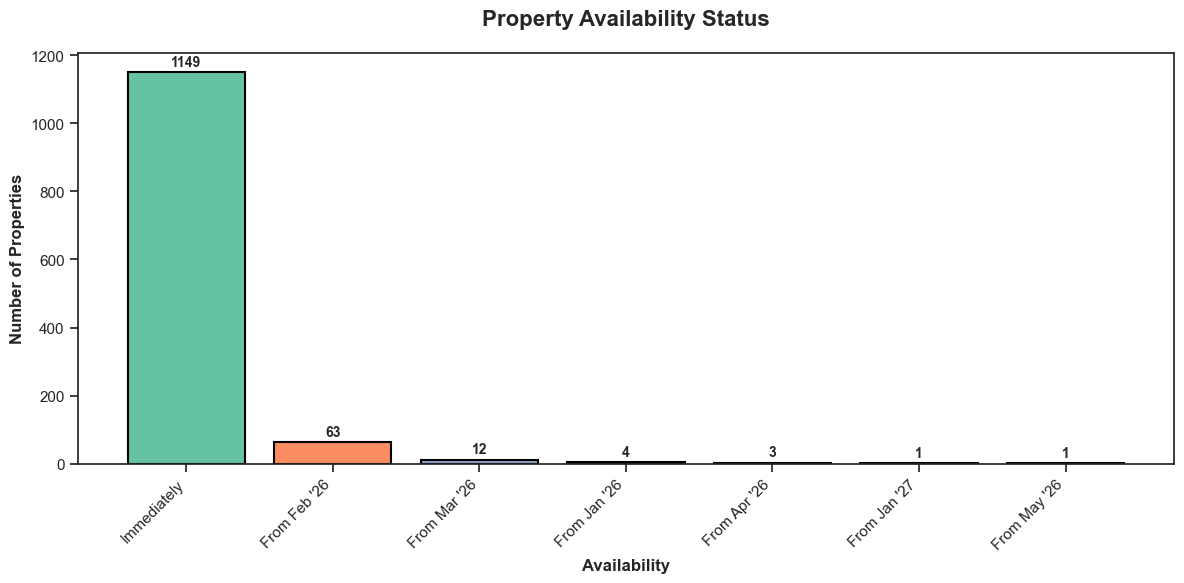

In [ ]:
# ============================================================================
# 13. AVAILABILITY STATUS
# ============================================================================
plt.figure(figsize=(12, 6))
availability_counts = df['Availability'].value_counts()
colors_avail = plt.cm.Set2(np.linspace(0, 1, len(availability_counts)))

plt.bar(range(len(availability_counts)), availability_counts.values, 
        color=colors_avail, edgecolor='black', linewidth=1.5)
plt.xticks(range(len(availability_counts)), availability_counts.index, rotation=45, ha='right')
plt.title('Property Availability Status', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Availability', fontsize=12, fontweight='bold')
plt.ylabel('Number of Properties', fontsize=12, fontweight='bold')

# Add value labels
for i, value in enumerate(availability_counts.values):
    plt.text(i, value + 10, f'{value}', ha='center', va='bottom', 
             fontweight='bold', fontsize=10)

plt.tight_layout()
plt.savefig('13_availability_status.png', bbox_inches='tight')
plt.show()



# Property Availability Status Analysis

## Overview
This bar chart illustrates the distribution of property availability across the dataset. It highlights whether properties are ready for immediate possession or have a scheduled future availability date.

## Key Insights

### 1. **Immediate Market Dominance**
- The overwhelming majority of properties—**1,149 listings**—are available **"Immediately"**.
- This indicates that the current rental market is highly active, with most landlords looking for instant occupancy.

### 2. **Future Availability**
- A small fraction of the market consists of properties with future move-in dates.
- **"From Feb '26"** is the second most common status with **63 properties**.
- Other categories like **"From Mar '26" (12)**, **"From Jan '26" (4)**, and beyond represent less than 2% of the total inventory combined.

### 3. **Market Liquidity**
- The high volume of "Immediately" available properties suggests high market horizontal liquidity, meaning renters have plenty of options to move in right away without waiting periods.

## Summary
The rental market captured in this data is primarily focused on **ready-to-move** units. Future-dated listings are rare, suggesting that most properties are either vacant or will be vacated shortly before being listed.


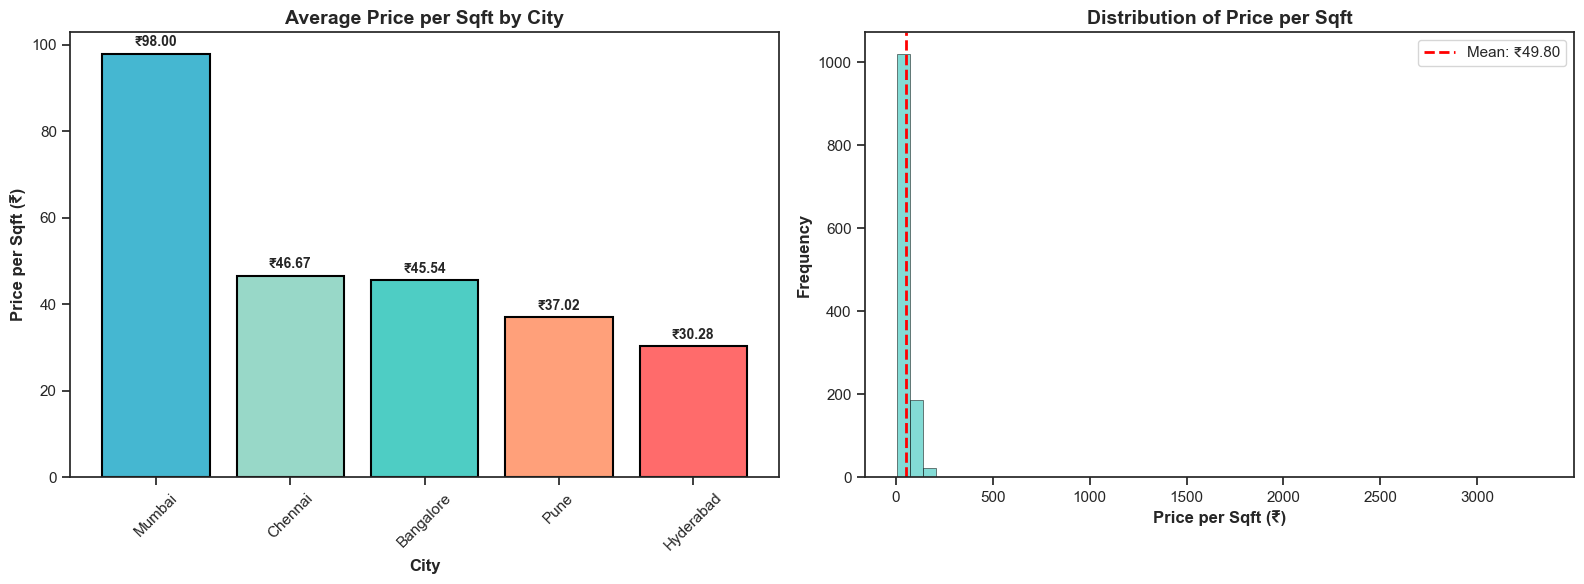

In [ ]:
# ============================================================================
# 14. PRICE PER SQFT ANALYSIS
# ============================================================================
df['Price_per_sqft'] = df['Price'] / df['Area (sqft)']

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Price per sqft by city
price_sqft_city = df.groupby('City')['Price_per_sqft'].mean().sort_values(ascending=False)
colors_sqft = [city_colors[city] for city in price_sqft_city.index]
axes[0].bar(price_sqft_city.index, price_sqft_city.values, color=colors_sqft, 
            edgecolor='black', linewidth=1.5)
axes[0].set_title('Average Price per Sqft by City', fontsize=14, fontweight='bold')
axes[0].set_xlabel('City', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Price per Sqft (₹)', fontsize=12, fontweight='bold')
axes[0].tick_params(axis='x', rotation=45)

# Add value labels
for i, (city, value) in enumerate(price_sqft_city.items()):
    axes[0].text(i, value + 1, f'₹{value:.2f}', ha='center', va='bottom', 
                 fontweight='bold', fontsize=10)
# Distribution of price per sqft
axes[1].hist(df['Price_per_sqft'], bins=50, color='#4ECDC4', 
             edgecolor='black', linewidth=0.5, alpha=0.7)
axes[1].set_title('Distribution of Price per Sqft', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Price per Sqft (₹)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Frequency', fontsize=12, fontweight='bold')
axes[1].axvline(df['Price_per_sqft'].mean(), color='red', linestyle='--', 
                linewidth=2, label=f'Mean: ₹{df["Price_per_sqft"].mean():.2f}')
axes[1].legend()

plt.tight_layout()
plt.savefig('14_price_per_sqft.png', bbox_inches='tight')
plt.show()



# Price per Square Foot Analysis

## Overview
This visualization provides a detailed look at the efficiency and value of rental space across different cities by calculating the **price per square foot (₹/sqft)**.

## Key Insights

### 1. City-Wise Average Comparison (Left Chart)
- **Mumbai (₹98.00)**: Significantly leads as the most "expensive" city per unit of area. Its rate is more than **twice** that of almost every other city.
- **Chennai (₹46.67)** and **Bangalore (₹45.54)**: Show very similar value-for-money metrics, sitting in the mid-range.
- **Pune (₹37.02)**: Offers better affordability for larger spaces.
- **Hyderabad (₹30.28)**: The most "cost-effective" city in terms of floor area, being nearly **3x cheaper** than Mumbai for the same amount of space.

### 2. Global Distribution (Right Chart)
- **Mean Rate**: The overall average across all cities is **₹49.80**.
- **Market Skew**: The distribution is extremely **right-skewed**. While the majority of the market sits comfortably below ₹100/sqft, there are extreme luxury outliers pushing rates into the thousands.
- **Cluster**: The highest frequency of listings is concentrated in the ₹20–₹60 range, representing the standard urban residential market.

## Summary
The study confirms that **Mumbai** is in a league of its own regarding space premium. For tenants, **Hyderabad** offers the best physical value for money, while the market as a whole is dominated by properties priced under the ₹50/sqft mark, despite the presence of high-end luxury exceptions.


In [21]:
# ============================================================================
# SUMMARY STATISTICS
# ============================================================================
print("\n" + "="*80)
print("EXPLORATORY DATA ANALYSIS SUMMARY")
print("="*80)
print(f"\nTotal Properties Analyzed: {len(df)}")
print(f"Cities Covered: {', '.join(df['City'].unique())}")
print(f"\nPrice Statistics:")
print(f"  - Average Rent: ₹{df['Price'].mean():,.2f}")
print(f"  - Median Rent: ₹{df['Price'].median():,.2f}")
print(f"  - Min Rent: ₹{df['Price'].min():,.2f}")
print(f"  - Max Rent: ₹{df['Price'].max():,.2f}")
print(f"\nArea Statistics:")
print(f"  - Average Area: {df['Area (sqft)'].mean():,.2f} sqft")
print(f"  - Median Area: {df['Area (sqft)'].median():,.2f} sqft")
print(f"\nMost Common:")
print(f"  - BHK: {df['BHK'].mode()[0]}")
print(f"  - Furnishing: {df['Furnishing'].mode()[0]}")
print(f"  - Property Type: {df['Property Type'].mode()[0]}")
print(f"  - Tenant Preference: {df['Tenant Preferred'].mode()[0]}")
print("\n" + "="*80)




EXPLORATORY DATA ANALYSIS SUMMARY

Total Properties Analyzed: 1233
Cities Covered: Hyderabad, Bangalore, Mumbai, Pune, Chennai

Price Statistics:
  - Average Rent: ₹51,948.94
  - Median Rent: ₹45,000.00
  - Min Rent: ₹4,500.00
  - Max Rent: ₹170,000.00

Area Statistics:
  - Average Area: 1,204.00 sqft
  - Median Area: 1,100.00 sqft

Most Common:
  - BHK: 3
  - Furnishing: Semi-Furnished
  - Property Type: Flat
  - Tenant Preference: Bachelors/Family

